# 2. Roughness - 2D

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions_2D import compute_surface_variance, compute_surface_roughness

## Dataframe computations

In [2]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_2D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [3]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
avg_df_path = "../Simulations_2D/average_simulations.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

Saved average simulations (560) to: ../Simulations_2D/average_simulations.pkl


In [4]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
TimeDep_delta0_L125_K1.0_T20000_M216,TimeDep,0.000000,0,1.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",216,20000,"[0.0, 0.04343448929682738, 0.04561405423062608...","[0.0, 0.043435791113398625, 0.0456157441160759..."
TimeDep_delta0_L250_K1.0_T20000_M94,TimeDep,0.000000,0,1.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",94,20000,"[0.0, 0.04347614686213526, 0.04566278674448989...","[0.0, 0.04347641937287254, 0.04566312057155149..."
TimeDep_delta0_L500_K1.0_T20000_M23,TimeDep,0.000000,0,1.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",23,20000,"[0.0, 0.04344119832108249, 0.04568786433011544...","[0.0, 0.043441252625870494, 0.0456879636326816..."
TimeDep_delta0_L1000_K1.0_T20000_M1,TimeDep,0.000000,0,1.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.043480720390408865, 0.0456108179558477...","[0.0, 0.043480720390408865, 0.0456108179558477..."
TimeDep_delta0_L125_K5.0_T20000_M16,TimeDep,0.000000,0,5.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",16,20000,"[0.0, 0.023155325039065113, 0.0237230601710162...","[0.0, 0.023157355215453142, 0.0237245629991319..."
TimeDep_delta0_L250_K5.0_T20000_M3,TimeDep,0.000000,0,5.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3,20000,"[0.0, 0.022937347939601328, 0.0239697648083804...","[0.0, 0.022937527053104114, 0.0239701442100463..."
TimeDep_delta0_L125_K10.0_T20000_M100,TimeDep,0.000000,0,10.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",100,20000,"[0.0, 0.017614619066983077, 0.0181916763437085...","[0.0, 0.017616153737050517, 0.0181942568912905..."
TimeDep_delta0_L250_K10.0_T20000_M61,TimeDep,0.000000,0,10.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",61,20000,"[0.0, 0.01764922025750833, 0.01818443094947499...","[0.0, 0.017649591325584173, 0.0181848437451244..."
TimeDep_delta0_L500_K10.0_T20000_M15,TimeDep,0.000000,0,10.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",15,20000,"[0.0, 0.017656908927665308, 0.0182061340107675...","[0.0, 0.017657081162194846, 0.0182063359371528..."


In [5]:
avg_df[(avg_df["K"] == 40) & (avg_df["T"] == 20000)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
Columnar_delta0_L125_K40.0_T20000_M225,Columnar,0.000000,0,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",225,20000,"[0.0, 0.78166551803856, 0.7957674745972362, 0....","[0.0, 0.7816684058966877, 0.7957714826162963, ..."
Columnar_delta0_L250_K40.0_T20000_M239,Columnar,0.000000,0,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",239,20000,"[0.0, 0.7813702007914233, 0.7955357451884557, ...","[0.0, 0.7813709709928669, 0.7955366853426895, ..."
Columnar_delta0_L500_K40.0_T20000_M60,Columnar,0.000000,0,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",60,20000,"[0.0, 0.7813401985477717, 0.7955260498046877, ...","[0.0, 0.7813403887478372, 0.7955262850731746, ..."
Columnar_delta0_L1000_K40.0_T20000_M1,Columnar,0.000000,0,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.7813916115534549, 0.7955376087930128, ...","[0.0, 0.7813916115534549, 0.7955376087930128, ..."
Columnar_deltaatan5_L125_K40.0_T20000_M228,Columnar,1.373401,atan5,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",228,20000,"[0.0, 0.07097898152251933, 0.08945305927646875...","[0.0, 0.07100881072792889, 0.08951960498799105..."
Columnar_deltaatan5_L250_K40.0_T20000_M238,Columnar,1.373401,atan5,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",238,20000,"[0.0, 0.07117073939568286, 0.08983257195220859...","[0.0, 0.07117779710579439, 0.08984721914763232..."
Columnar_deltaatan5_L500_K40.0_T20000_M59,Columnar,1.373401,atan5,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",59,20000,"[0.0, 0.07095961850973302, 0.08947545907235202...","[0.0, 0.0709614056444685, 0.08947927352316408,..."
Columnar_deltaatan5_L1000_K40.0_T20000_M1,Columnar,1.373401,atan5,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.07121714513644721, 0.08990563036510325...","[0.0, 0.07121714513644721, 0.08990563036510325..."


In [6]:
avg_df.describe()

,delta,K,L,M,T
count,30.000000,30.000000,30.000000,30.000000,30.0
mean,0.686700,30.233333,341.666667,67.733333,20000.0
std,0.698440,35.274963,264.520820,83.000180,0.0
min,0.000000,1.000000,125.000000,1.000000,20000.0
25%,0.000000,5.000000,125.000000,7.000000,20000.0
50%,0.686700,10.000000,250.000000,25.000000,20000.0
75%,1.373401,40.000000,500.000000,98.500000,20000.0
max,1.373401,100.000000,1000.000000,239.000000,20000.0


## Inspection of the computed quantities

In [7]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers_evolution import plot_roughness_evolution
from plotting_helpers_collapse import plot_roughness_collapse

In [8]:
avg_df_path = "../Simulations_2D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [13]:
T = 20000
Ks = [5, 40]

### Large coupling = KPZ, EW

In [14]:
markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

In [15]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


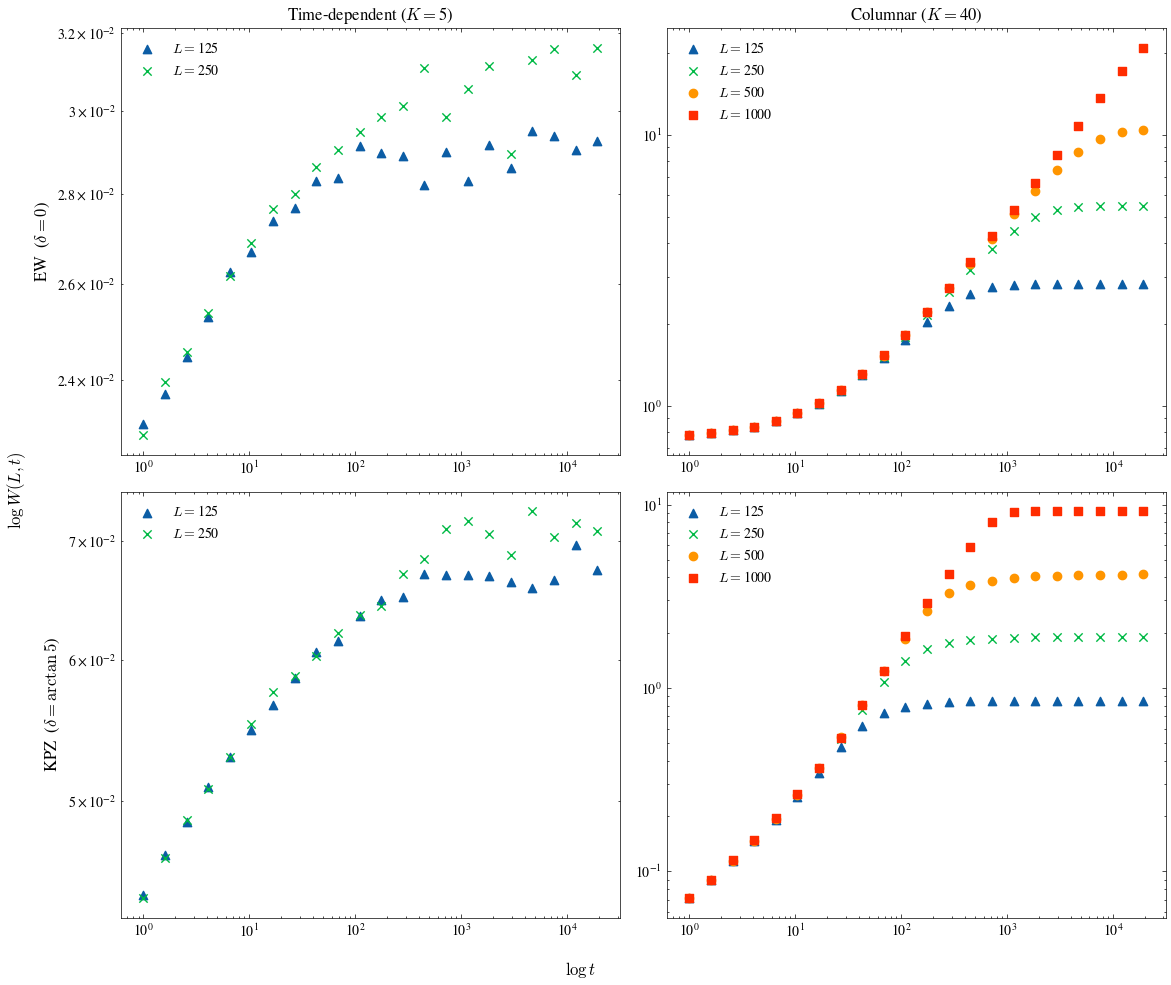

In [16]:
plot_roughness_evolution(avg_df, T, tx, Ks=Ks)

- puede que el inicio columnar sea un periodo de relajación para olvidar la condición inicial
- más acople en el columnar (para reducir el ruido y con ello la condición inicial)
- obtener las pendientes de los casos Columnar para calcular sus betas, pasado el inicio.
- reducir el coupling en el dependiente del tiempo porque aquí puede estar pasando de regimen EW a saturación directamente, sin dar tiempo a KPZ. Reducir el coupling $K$ ayuda (porque el acople de KPZ va como $g=lambda^2 D/nu^3 \sim 1/K$, alternativamente cambiar la tangente de 5 para ayudar al término KPZ.

In [12]:
(t[1],t[2]),(t[9],t[10]),(t[-2],t[-1])

((np.float64(1.00000050000025), np.float64(1.6000008000004002)),
 (np.float64(42.94002147001074), np.float64(68.71003435501719)),
 (np.float64(12089.256044628024), np.float64(19342.819671409838)))

In [16]:
for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname, nameeq) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"], ["EW","KPZ"])):

        print("##", nameeq, "( δ =",deltaname,")")
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            # & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
        
            if L == 500:
                print("-- loglog Slopes --")
                slope_initial = np.log(mean_roughness[2]) - np.log(mean_roughness[1])
                slope_initial /= (np.log(t[2]) - np.log(t[1]))
                slope_medium = np.log(mean_roughness[10]) - np.log(mean_roughness[9])
                slope_medium /= (np.log(t[10]) - np.log(t[9]))
                slope_final = np.log(mean_roughness[-2]) - np.log(mean_roughness[-1])
                slope_final /= (np.log(t[-2]) - np.log(t[-1]))
                print("β =",np.round(slope_initial,2), np.round(slope_medium,2), np.round(slope_final,2))
                print()
                    

# TimeDep
## EW ( δ = 0 )
-- loglog Slopes --
β = 0.07 0.06 0.04

## KPZ ( δ = atan5 )
-- loglog Slopes --
β = 0.09 0.05 -0.01

# Columnar
## EW ( δ = 0 )
-- loglog Slopes --
β = 0.04 0.34 0.04

## KPZ ( δ = atan5 )
-- loglog Slopes --
β = 0.49 0.9 0.01



# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


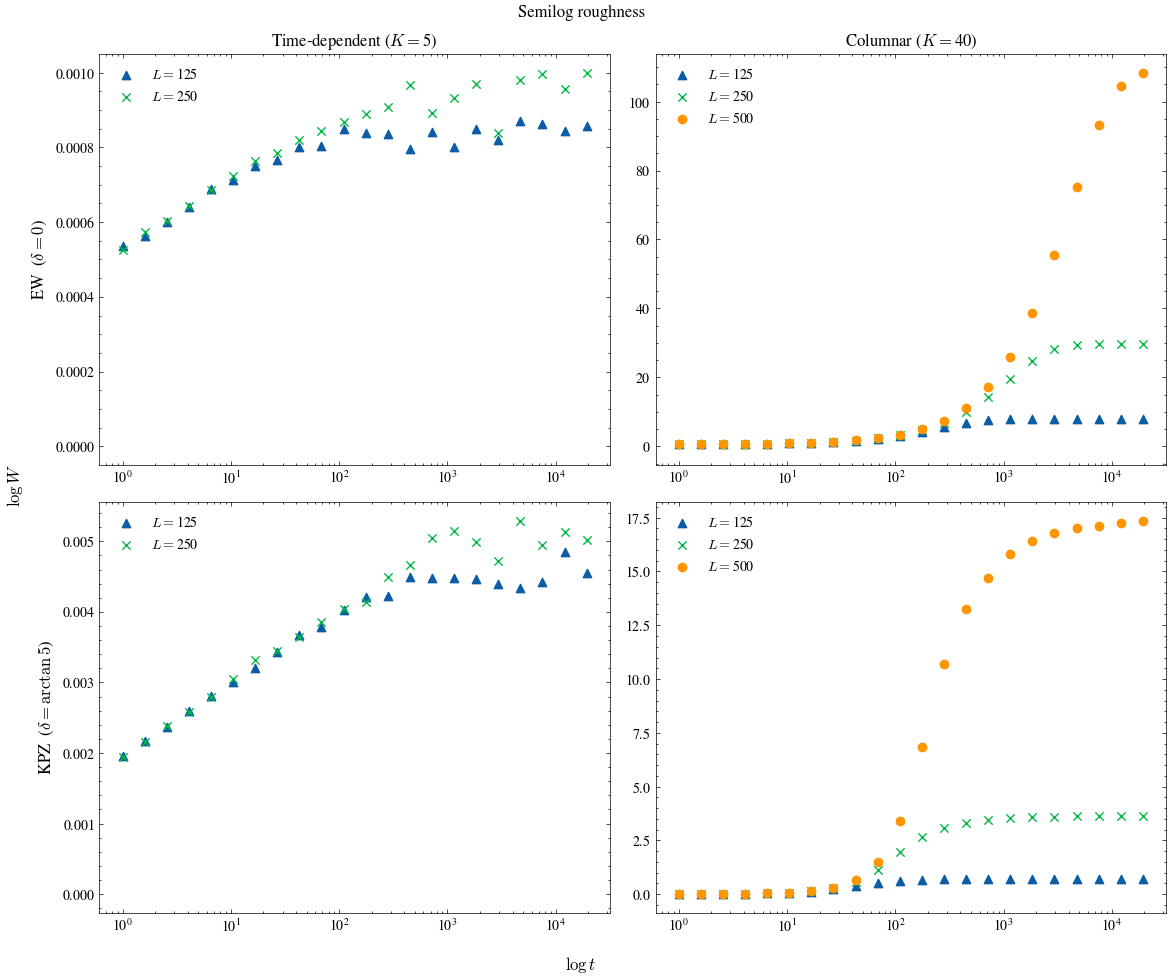

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(12,10))
fig.suptitle("Semilog roughness")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        print("##", deltaname)
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
                    
            ax[j,i].scatter(t, mean_roughness**2, label=r"$L=$" + str(L), marker=markerdict[L])

        ax[j,i].set_xscale('log')
        # ax[j,i].set_yscale('log')
        
    # Scalings
    #ax[0,0].semilogx(t[1:-5:], 0.0022 + np.log(t[1:-5:])/2600, linestyle="--", color="k")

ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")      
ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

In [84]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": 0.34, "KPZ": 0.93}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

#### Family-Vicsek collapse

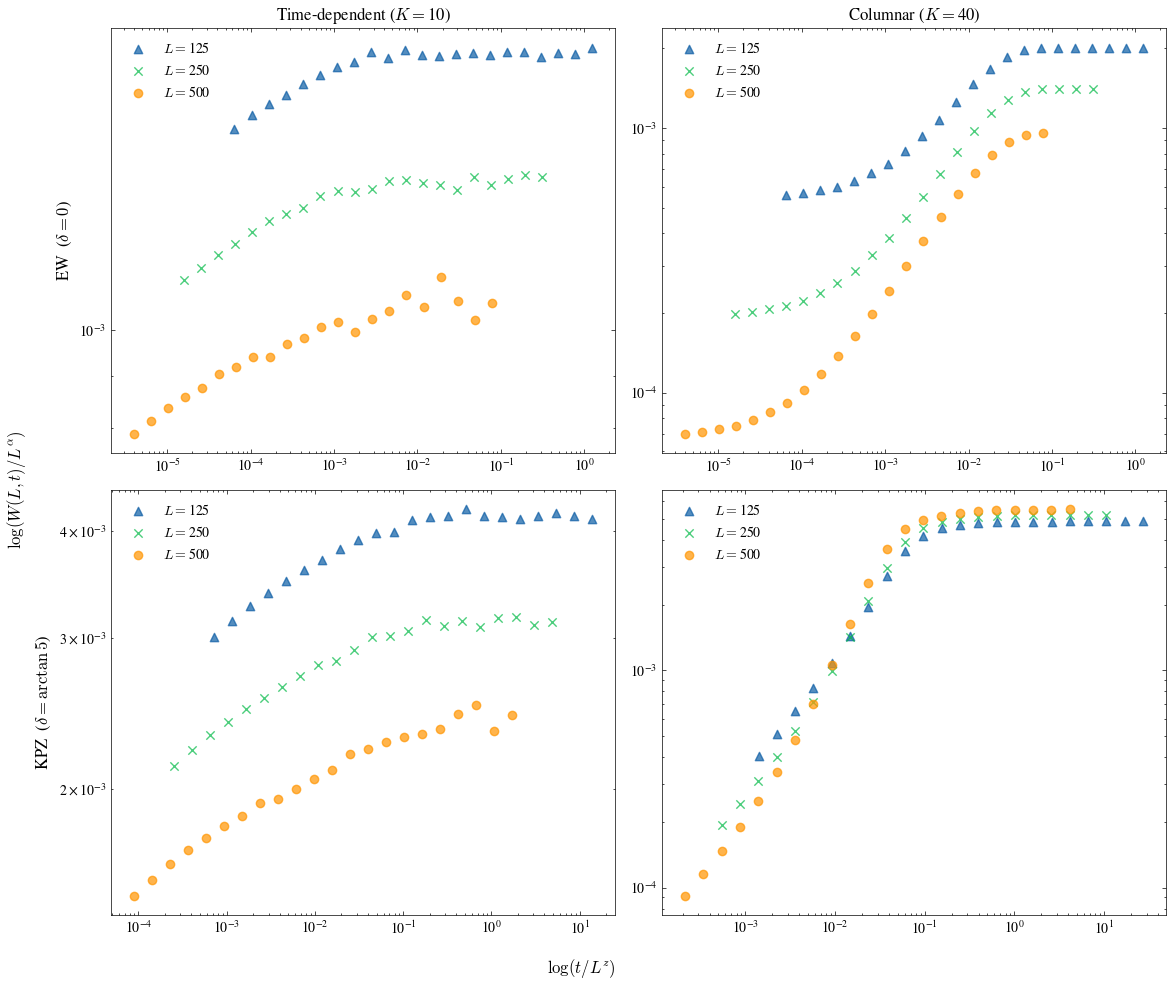

In [86]:
plot_roughness_collapse(avg_df, T, tx, Ks=Ks)

### Small coupling in time dependent, KPZ

In [42]:
typenoise = "TimeDep"
typelabel = "Time-dependent noise"
deltaname = "atan5"

markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

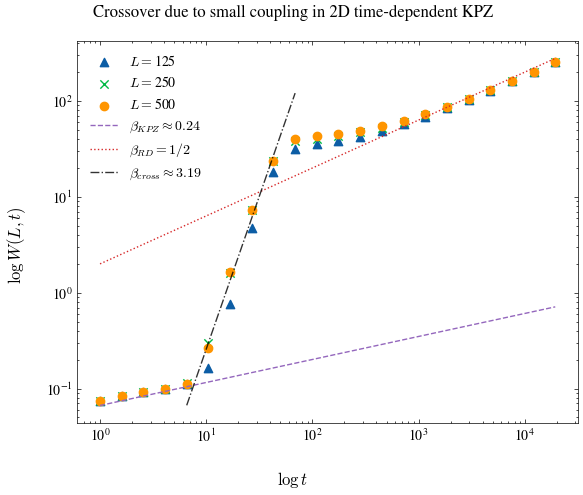

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
fig.suptitle("Crossover due to small coupling in 2D time-dependent KPZ")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W(L,t)$")

# select rows for this noise type and delta
mask = mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["deltaname"] == deltaname)
    & (avg_df["T"] == T)
    & (avg_df["K"] == 1)
    & (avg_df["L"] < 1000)
)
sub_df = avg_df[mask]

# in case there are multiple (K, L) combos, plot them all
for _, row in sub_df.iterrows():
    t = row["t"]
    mean_roughness = row["mean_roughness"]
    L = row["L"]
    K = row["K"]                    
    
    ax.scatter(t, mean_roughness, label=r"$L=$" + str(L), marker=markerdict[L])

ax.set_xscale('log')
ax.set_yscale('log')

# Scalings
ax.loglog(t[1:], t[1:]**(0.24) /15, label=r"$\beta_{KPZ} \approx 0.24$", linestyle="--", color="tab:purple", alpha=1)
ax.loglog(t[1:], t[1:]**(0.5) * 2, label=r"$\beta_{RD} = 1/2$", linestyle=":", color="tab:red", alpha=1)
ax.loglog(t[5:11], t[5:11]**(3.19) /6000, label=r"$\beta_{cross} \approx 3.19$", linestyle="dashdot", color="k", alpha=0.8)

ax.legend()

plt.tight_layout()
plt.show()

In [74]:
(t[1],t[2]),(t[7],t[8]),(t[-2],t[-1])

((np.float64(1.00000050000025), np.float64(1.6000008000004002)),
 (np.float64(16.770008385004193), np.float64(26.840013420006713)),
 (np.float64(12089.256044628024), np.float64(19342.819671409838)))

In [75]:
# select rows for this noise type and delta
mask = mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["deltaname"] == deltaname)
    & (avg_df["T"] == T)
    & (avg_df["K"] == 1)
    # & (avg_df["L"] < 1000)
)
sub_df = avg_df[mask]

# in case there are multiple (K, L) combos, plot them all
for _, row in sub_df.iterrows():
    t = row["t"]
    mean_roughness = row["mean_roughness"]
    L = row["L"]
    K = row["K"]

    if L == 500:
        print("#", typenoise)
        print("##", nameeq, "( δ =",deltaname,")")
        print("-- loglog Slopes --")
        slope_initial = np.log(mean_roughness[2]) - np.log(mean_roughness[1])
        slope_initial /= (np.log(t[2]) - np.log(t[1]))
        slope_medium = np.log(mean_roughness[7]) - np.log(mean_roughness[8])
        slope_medium /= (np.log(t[7]) - np.log(t[8]))
        slope_final = np.log(mean_roughness[-2]) - np.log(mean_roughness[-1])
        slope_final /= (np.log(t[-2]) - np.log(t[-1]))
        print("β =",np.round(slope_initial,2), np.round(slope_medium,2), np.round(slope_final,2))
        print()
            

# TimeDep
## KPZ ( δ = atan5 )
-- loglog Slopes --
β = 0.24 3.19 0.48

